**4장 - 모델 훈련**

# 설정

이 프로젝트는 파이썬 3.7 이상이 필요함

In [1]:
import sys

assert sys.version_info >= (3, 7)

또한 사이킷런 ≥ 1.0.1이 필요합니다:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

기본 글꼴 크기 정의 :

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

이미지 path 지정: 

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 선형 회귀

일반적인 선형 모델은 
$$
\hat{y} = \theta _0 + \theta _1 x_1 + \theta _2 x_2 + ... + \theta _n x_n
$$

선형 회귀 모델의 예측 식처럼 익렵 특성의 가중치 합과 **편향(bias)** (또는 **절편(intercept)**)이라는 상수를 더해 예측함
 
- $ \hat{y} $ : 예측값
- $ n $ : 특성의 수
- $ x_i $ : $i$번째 특성값
- $ \theta _j $ : $j$번째 모델 파라미터

이 식은 

$$
\hat{y}
= h_{\boldsymbol{\theta}}(\mathbf{x})
= \boldsymbol{\theta} \cdot \mathbf{x}
$$

이처럼 벡터 형태로 더 간단하게 쓸 수 있음.

- $h_0$ : 모델 파라미터 $\boldsymbol{\theta}$를 사용한 가설 함수
- $\boldsymbol{\theta}$ : 편향 $\theta _0$과 $\theta _1$에서 $\theta _n$까지의 가중치를 담은 모델의 파라미터 벡터
- $\boldsymbol{x}$ : $x_0$에서 $x_n$까지 담은 샘플의 **특성 벡터**. $x_0$은 항상 1
- $\boldsymbol{\theta} \cdot \boldsymbol{x}$ : 벡터 $\boldsymbol{\theta}$ 와 $\boldsymbol{x_0}$의 점곱. $\theta _0 + \theta _1 x_1 + \theta _2 x_2 + ... + \theta _n x_n$ 과 같음


모델을 훈련시킨 다는 것은 모델이 훈련 세트에 가장 잘 맞도록 모델 파라미터를 설정하는 것.

이를 하기 위해서 먼저 모델이 훈련 데이터에 얼마나 잘 맞는지 측정해야함. 회귀에서 가장 널리 사용되는 성능 측정 지표는 **평균 제곱츤 고차 (RMSE)**.
그러므로 선형 회귀 모델을 훈련시키기려면 RMSE를 최소화 하는 $\boldsymbol{\theta}$를 찾아야함.

훈련 세트 $\boldsymbol{X}$ 에 대한 선형 회귀 가서 $h_0$의 MSE는 아래와 같이 계산함.
$$
MSE(\boldsymbol{X}, h_\theta) = \frac{1}{m} \sum_{i=1}^{m}(\boldsymbol{\theta}^T \boldsymbol{x}^{(i)} - y^{i})^{2}
$$
이 계산식에서는 $MSE(\boldsymbol{X}, h_\theta)$ 대신 $MSE(\boldsymbol{\theta})$ 표시가능

## 정규 방정식

비용 함수를 최소화 하는 $\boldsymbol{\theta}$ 값을 찾기 위한 **해석적인 방법**이 있음.다른 말로 하면 결과를 바로 얻을 수 있느 수학 공식이 있음. 이를 **정규 방정식(normal equation)** 이라고 함

정규 방정식:
$$
\hat{\boldsymbol{\theta}} = (\boldsymbol{X}^{T} \boldsymbol{X})^{-1} \boldsymbol{X}^T \boldsymbol{y}
$$

- $\hat{\boldsymbol{\theta}}$ : 비용 함수를 최소화하는 $\boldsymbol{\theta}$ 값
- $\boldsymbol{y}$ : $y^{(1)}$ 부터 $y^{(m)}$ 까지 포함하는 타깃 벡터

공식 테스트를 위한 선형 처럼 보이는 데이터 생성 : 

In [5]:
import numpy as np

np.random.seed(42)
m = 100  # 샘플 개수
X = 2 * np.random.rand(m, 1)  # 열 벡터
y = 4 + 3 * X + np.random.randn(m, 1)  # 열 벡터

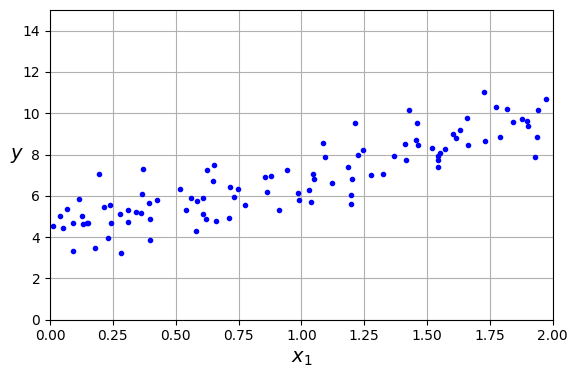

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("generated_data_plot")
plt.show()

정규 방정식을 사용해 $\hat{\boldsymbol{\theta}}$를 계산하는 코드 :

In [7]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # 각 샘플에 x0 = 1을 추가
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [8]:
theta_best

array([[4.21509616],
       [2.77011339]])

 $\hat{\boldsymbol{\theta}}$ 을 사용해 예측 : 

In [9]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # 각 샘플에 x0 = 1을 추가
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

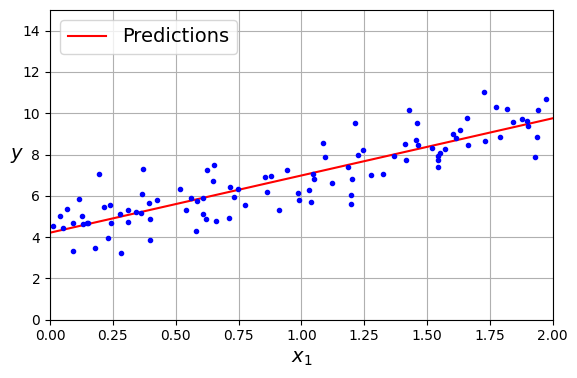

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
save_fig("linear_model_predictions_plot")

plt.show()

In [11]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [12]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

`LinearRegression` 클래스는 `scipy.linalg.lstsq()` 함수("least squares"의 약자)를 사용하므로 이 함수를 직접 사용할 수 있음:

In [13]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

이 함수는 $\hat{\mathbf{\theta}} = \mathbf{X}^+\mathbf{y}$을 계산함. $\mathbf{X}^{+}$는 $\mathbf{X}$의 **유사역행렬 (pseudoinverse)** 임. ( 정확하게는 Moore–Penrose 유사역행렬). `np.linalg.pinv()`을 사용해서 유사역행렬을 직접 계산할 수 있습니다:

In [14]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

유사역행렬 자체는 **특잇값 분해(singular value decomposition, SVD)** 라 부르는 표준 행렬 분해 기법을 사용해 계산됨. 

SVD는 훈련 세트 행렬 $\boldsymbol{X}$ 를 3개의 행렬곱셈 $\mathbf{U}\mathbf{\Sigma}\mathbf{V}^{T}$로 분해함

유사 역행렬은 $\mathbf{X}^{+} = \mathbf{V} \mathbf{\Sigma}^{+} \mathbf{U}^{T}$로  계산됨.

$\mathbf{\Sigma}^{+}$를 계산하기 위해 알고리즘이  $\mathbf{\Sigma}$를 먼저 구한 다음 어떤 낮은 임곗값 보다 작은 수를 0으로 바꿈. 그 다음 0이아닌 모든 값을 역수로 치환, 마지막으로 만들어진 행렬을 전치함. 

정규 방정식을 계산하는 것보다 이 방식이 훨씬 효율적임. 또한 극단적인 경우도 처리할 수 있음.

실제로 $m<n$ 이거나 어떤 특성이 중복되어 행렬 $\mathbf{X}^{T} \mathbf{X}$의 역행렬이 없다면 정규 방정식이 작동하지 않음. 하지만 유사역행렬은 항상 구할 수 있음.

## 계산 복잡도

정규 방정식은 $(n + 1) \times (n+1)$ 크기의 $\mathbf{X}^T \mathbf{X}$의 역행렬을 계산함.($n$은 특성의 수) 일반적으로 역행렬을 계산하는 **시간 복잡도 (computational complexity)** 는 일반적으로 $O(n^{2.4})$ 에서 $O(n^{3})$ 사이임. (구현 방법에 따라 차이가 있음.) 즉, 특성 수가 두 배로 늘어나면 계산 시간이 대략 $2^{2.4} = 5.3$배 에서 $2^{3} = 8$배로 늘어날 수 있음.

정리하자면 샘플링의 개수에따라 훈련시간이 배로 늘어남

# 경사하강법

**경사 하강법 (gradient descent, GD)** 은 여러 종류의 문제에서 최적의 해법을 찾을 수 있는일반적인 최적화 알고리즘임. 경사 하강법의 기본 아이디어는 비용 함수르 최소화하기 위해 반복해서 파라미터를 조정하는 것

경사 하강법은 파라미터 벡터 $\boldsymbol{\theta}$에 대해 비용 함수의 현재 그레디언트(gradient)를 계산함. 그리고 게이디언트가 감소하는 방향으로 진행함. 그레이디언트가 0이 되면 최솟값에 도달한 것.

구체적으로 보면 $\boldsymbol{\theta}$을 임의의 값으로 시작해서 (**랜덤 초기화(random initalizatoin)** 이라고함) 한 버네 조금식 비용 함수(MSE)를 감소하는 방향으로 진행하여 알고리즘이 최솟값에 수렴할 때까지 점진적으로 향상

경사 하강법에서 중요한 파라미터는 스텝의 크리고, **학습률(learning rate)** 하이퍼 파라미터로 결정됨. 학습률이 너무 작으면 알고리즘이 수렴하기 위해 반복을 많이 진행해야하기 때문에 시간이 오래 걸림. 반대로 너무 너무 크면 골짜기를 가로 질러 반대방향으로 건너뛰게 되어 이전 보다 더 높은 곳으로 올라가게됨

경사하강법은 임의의로 시작점을 두기 때문에 바로 **전역 최솟값(global minimum)** 에 가면 좋겠지만 시작위치에 따라 지역 **최솟값(local minimum)** 에 빠질수도 있음.

하지만 다행이도 MSE의 곡선은 **볼록 함수(convex function)** 이기 때문에 지역 최솟값이 없고 하나의 전역 최솟값만 있음.

모델 훈련이 훈련 세트에서 비용함수를 최소화하는 모델 파라미터의 조합을 찾는일을 함. 이를 "**파라미터 공간(Parameter space)**에서 찾는다" 라고 표현함.

모델이 가진 파라미터가 많을수록 이 공간의 차원은 커지고 검색은 어려워짐

## 배치 경사 하강법

경사 하강법을 구현하려면 각 모델 파라미터 $\theta _j$ 에 대해 비용함수의 그레이디언트를 계산해함. 다시 말해 $\theta _j$가 조금 변겨오딜 때 비용 함수가 얼마나 바뀌는지 계산해야함. 이름 **편향도함수(partial derivative)** 라고함

비용 함수의 편도함수 :
$$
\frac{\partial}{\partial \theta _j}MSE(\boldsymbol{\theta}) =
\frac{2}{m} \sum_{i=1}^m(\boldsymbol{\theta}^{T} \boldsymbol{x}^{(i)} - y^{(-1)})x_j^{(i)}

$$ 

비용함수를 각각 계산하는 대신 비용함수의 그레이디언트 벡터식을 사용하여 한 번에 계산 가능

비용 함수의 그레이디언트 벡터:

$$
\nabla _{\boldsymbol{\theta}} = 
\begin{pmatrix}
\frac{\partial}{\partial \theta _0}MSE(\boldsymbol{\theta}) \\
\frac{\partial}{\partial \theta _1}MSE(\boldsymbol{\theta}) \\
\vdots  \\
\frac{\partial}{\partial \theta _n}MSE(\boldsymbol{\theta})
\end{pmatrix} = \frac{2}{m} \boldsymbol{X}^{T}(\boldsymbol{X\theta - y})
$$

위로 향하는 그레이디언트 벡터가 구해지면 반대 방향인 아래로 가야합니다. $\boldsymbol{\theta}$에서 $\nabla _{\boldsymbol{\theta}}MSE(\boldsymbol{\theta})$ 를 빼야한다는 뜻. 여기서 학습률 $\eta$가 사용됨. 내려가는 스템의 크기를 결정하기 위해 그레이디언트 벡터에 $\eta$를 곱함 

경사 하강법의 스탭 :

$$
\boldsymbol{\theta}^{(next step)} = \boldsymbol{\theta} - \eta \nabla _{\boldsymbol{\theta}} MSE(\boldsymbol{\theta})
$$

In [15]:
eta = 0.1 # 학습률
n_epochs = 1000
m = len(X_b) # 샘플 개수

np.random.seed(42)
theta = np.random.randn(2,1) # 모델 파라미터를 랜덤하기 초기화

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

In [16]:
theta

array([[4.21509616],
       [2.77011339]])

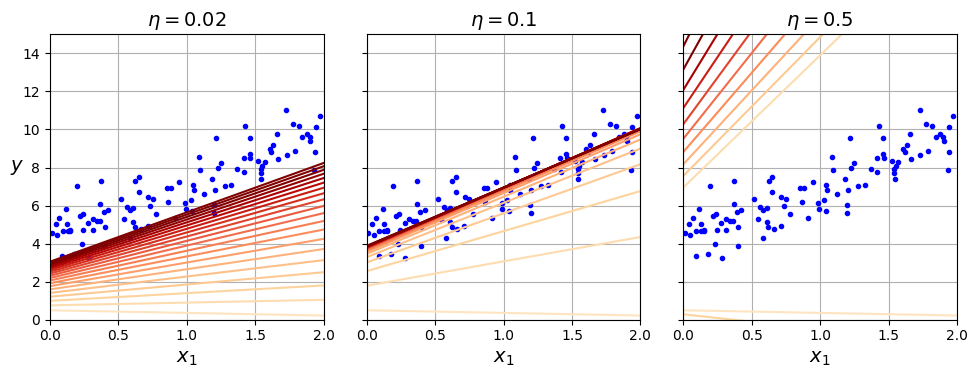

In [17]:
import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # 랜덤 초기화

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
save_fig("gradient_descent_plot")
plt.show()

## 확률적 경사 하강법

배치 경사 하강법의 문제점 : 매 스테베엇 전체 훈련 세트를 사용해 그레이디언트를 계산함 -> 후련세트가 커지면 속도가 매우 느려짐.

확률적 경사 하강법으 매 스텝에서 한 개의 샘플을 랜덤으로 선택하고 그 하나의 샘플에 대한 그레이디언트를 계산하기 때문에, 매 반복에서 다뤄야할 데이터가 매우 적어져 알고리즘이 확실히 빠름.

하지만 배치 경사 하강법 모다 불안정함. 랜덤적으로 가기 때문에 직선으로 유연히 값을 찾는 배치 경사하강법 보다 불안 정함. 하지만 위아래로 움직이며 그래프가 그려지기 때문에 지역최소값보다 전역 최소값을 찾을 수 있음. 

이 딜레마를 해결한게 점진적으로 랜덤 범위를 줄이는 방법임. 매 반복에서 학습률을 결정하는 함수르를 **학습 스케줄(learning schedule)**이라고 함.

In [18]:
theta_path_sgd = []

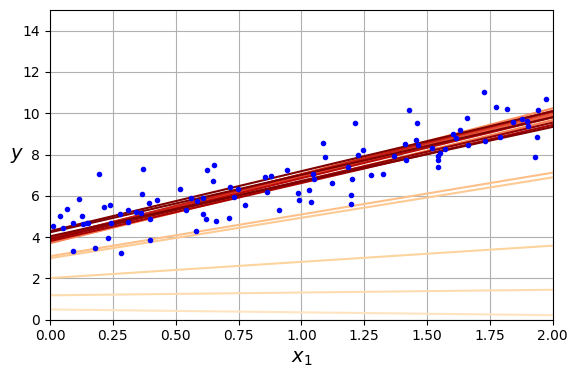

In [19]:
n_epochs = 50
t0, t1 = 5, 50  # 학습 스케줄 하이퍼파라미터

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)  # 랜덤 초기화

n_shown = 20  
plt.figure(figsize=(6, 4))

for epoch in range(n_epochs):
    for iteration in range(m):

        if epoch == 0 and iteration < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
            plt.plot(X_new, y_predict, color=color)

        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # SGD의 경우 m으로 나누지 않음.
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)

plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("sgd_plot")
plt.show()

In [20]:
theta

array([[4.21076011],
       [2.74856079]])

In [21]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())  # fit()이 1D 타깃을 기대하기 때문에 y.ravel()로 씀

SGDRegressor(n_iter_no_change=100, penalty=None, random_state=42, tol=1e-05)

In [22]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))